<a href="https://colab.research.google.com/github/abhishekanand04/ML-Supervised-Algorithms/blob/supervised-alogorithm/kNN1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
!gdown 1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2


Downloading...
From: https://drive.google.com/uc?id=1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2
To: /content/multiclass.csv
100% 14.6k/14.6k [00:00<00:00, 28.4MB/s]


In [ ]:
df=pd.read_csv('multiclass.csv')
df.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
0,3,12669,9656,7561,214,2674,1338,2
1,3,7057,9810,9568,1762,3293,1776,2
2,3,6353,8808,7684,2405,3516,7844,2
3,3,13265,1196,4221,6404,507,1788,1
4,3,22615,5410,7198,3915,1777,5185,1


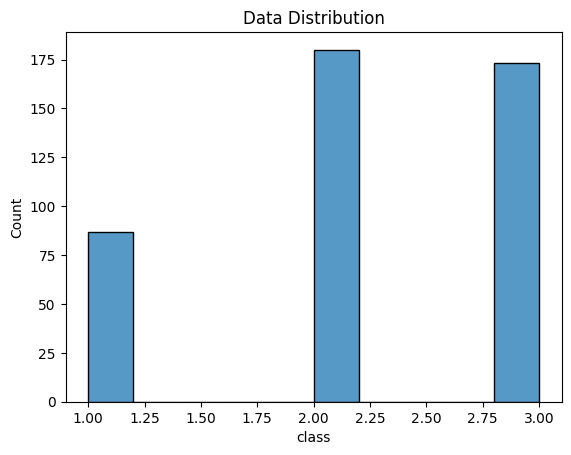

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="class")
plt.title('Data Distribution')
plt.show()

In [ ]:
X=df[['Region',	'Fresh',	'Milk',	'Grocery',	'Frozen',	'Detergents_Paper',	'Delicassen'	]].copy()
y=df[['class']].copy()

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def scatter_visualize(visualize1,visualize2,y_label):
  scatter = plt.scatter(visualize[:,0] ,visualize[:,1],c = y.values[:,0] )
  plt.legend(handles=scatter.legend_elements()[0], labels=['Class1','Class2','Class3'])
  plt.show()

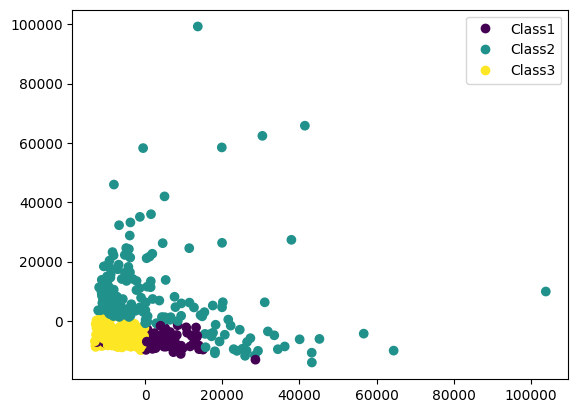

In [ ]:
# reducing features to just 2 features for visualization purpose
pca = PCA(n_components=2)
visualize = pca.fit_transform(X)


scatter_visualize(visualize[:,0] ,visualize[:,1],y.values[:,0])


In [ ]:
from scipy.stats import mode

arr = np.array([1, 2, 2, 3, 3, 3,3, 4])
mode(arr)

ModeResult(mode=np.int64(3), count=np.int64(4))

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_train_val, X_test, y_train_val, y_test = train_test_split(X,y,test_size=0.25, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_val,y_train_val,test_size=0.25, random_state=42)

In [ ]:
from imblearn.over_sampling import SMOTE

# Create an instance of SMOTE
smt = SMOTE()

X_sm, y_sm = smt.fit_resample(X_train, y_train)

In [ ]:
y_train.value_counts()

,count
class,
3,99
2,95
1,53


In [ ]:
y_sm.value_counts()

,count
class,
1,99
2,99
3,99


In [ ]:
from sklearn.preprocessing import StandardScaler

st =  StandardScaler()

X_sm = st.fit_transform(X_sm.values)
X_val_scaled = st.transform(X_val.values)
X_test_scaled = st.transform(X_test.values)

y_sm = y_sm.values[:,0]
y_val = y_val.values[:,0]
y_test = y_test.values[:,0]

In [ ]:
from scipy.stats import mode

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

class KNN:
    def __init__(self, k=3):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        # Compute distances between x and all examples in the training set
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        # Sort by distance and return indices of the first k neighbors
        k_idx = np.argsort(distances)[: self.k]
        # Extract the labels of the k nearest neighbor training samples
        k_neighbor_labels = [self.y_train[i] for i in k_idx]

        return mode(k_neighbor_labels)[0]

In [ ]:
model = KNN(k=3)
model.fit(X_sm, y_sm)
y_pred= model.predict(X_val_scaled)
y_pred

array([3, 2, 2, 2, 3, 2, 3, 1, 3, 3, 2, 2, 1, 3, 2, 3, 3, 3, 1, 3, 1, 1,
       2, 2, 1, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 1, 3, 3, 3, 3, 1, 2,
       3, 3, 1, 3, 2, 3, 3, 2, 1, 3, 2, 2, 3, 3, 3, 1, 1, 2, 1, 1, 3, 2,
       2, 1, 3, 2, 2, 2, 2, 2, 3, 2, 1, 3, 1, 2, 3, 3, 2])

In [ ]:
np.sum(y_val == y_pred).astype(int)/y_pred.shape[0]

np.float64(0.9156626506024096)

In [ ]:
model = KNN(k=5)
model.fit(X_sm, y_sm)
y_pred= model.predict(X_val_scaled)

In [ ]:
np.sum(y_val == y_pred).astype(int)/y_val.shape[0]

np.float64(0.8795180722891566)

In [ ]:
y_pred_sample = model.predict(X_val_scaled[50,:].reshape(1,-1))
y_pred_sample

array([3])

In [ ]:
y_test.shape

(110,)

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred= model.predict(X_test_scaled)

cm = confusion_matrix(y_test,y_pred)


In [ ]:
 np.unique(y_test,return_counts=True)

(array([1, 2, 3]), array([20, 47, 43]))

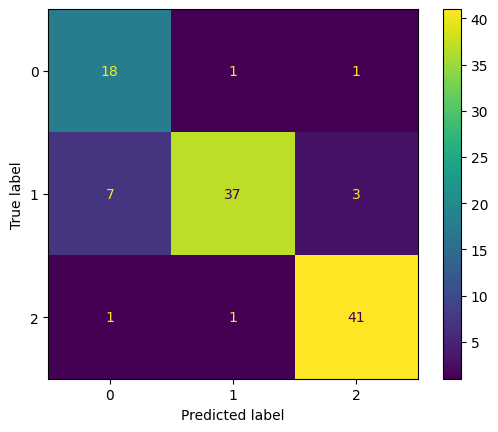

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm).plot()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.69      0.90      0.78        20
           2       0.95      0.79      0.86        47
           3       0.91      0.95      0.93        43

    accuracy                           0.87       110
   macro avg       0.85      0.88      0.86       110
weighted avg       0.89      0.87      0.87       110



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt


knn = KNeighborsClassifier(n_neighbors=5,metric='euclidean')
knn.fit(X_sm, y_sm)


KNeighborsClassifier(metric='euclidean')

In [ ]:
from sklearn.metrics import classification_report

y_pred = knn.predict(X_test_scaled)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.69      0.90      0.78        20
           2       0.95      0.79      0.86        47
           3       0.91      0.95      0.93        43

    accuracy                           0.87       110
   macro avg       0.85      0.88      0.86       110
weighted avg       0.89      0.87      0.87       110



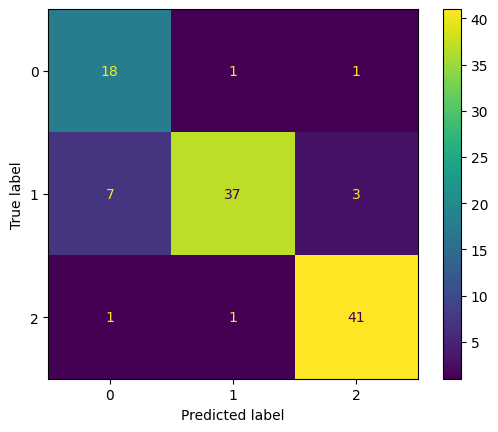

In [ ]:
y_pred = knn.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

In [ ]:
Acc = []

# Calculating error for K values between 1 and 50
# Note: 51 is not included in the loop
for i in range(1, 51):
    knn = KNeighborsClassifier(n_neighbors=i,metric='euclidean')
    knn.fit(X_sm, y_sm)

    Acc.append(knn.score(X_val_scaled,y_val))

Text(0, 0.5, 'Accuracy')

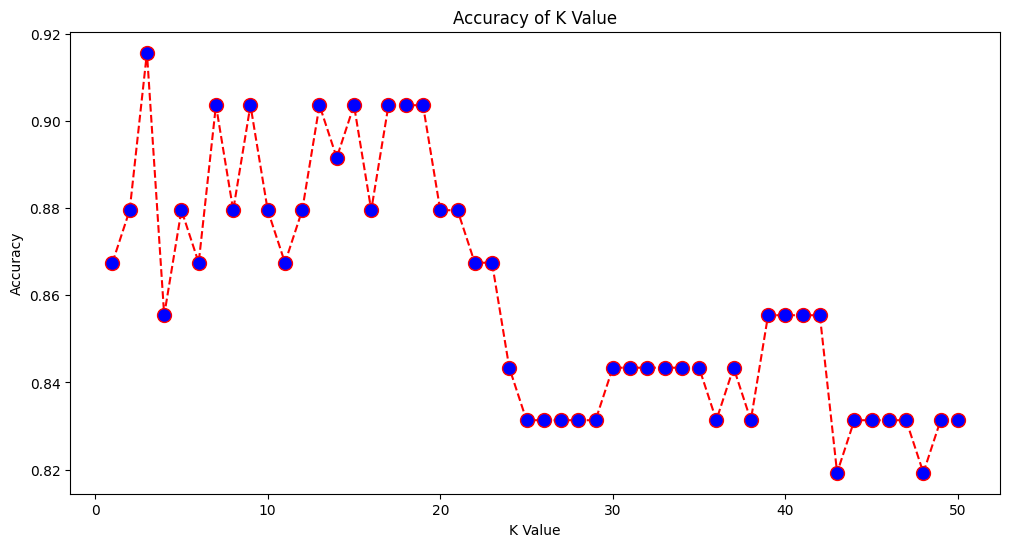

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 51), Acc, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Accuracy of K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')

In [ ]:
!gdown 1vDIXh1yJxLpmgdh3gZGM6WX0u3GCPuIS


Downloading...
From: https://drive.google.com/uc?id=1vDIXh1yJxLpmgdh3gZGM6WX0u3GCPuIS
To: /content/knn_imputation.csv
100% 12.9k/12.9k [00:00<00:00, 3.35MB/s]


In [ ]:
import pandas as pd
import numpy as np

df_imp = pd.read_csv('knn_imputation.csv')
df_imp.drop(['Unnamed: 0'],axis=1,inplace=True)

In [ ]:
df_imp.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,3.0,12669.0,9656.0,7561.0,214.0,2674.0,1338.0
1,3.0,7057.0,9810.0,9568.0,1762.0,3293.0,1776.0
2,3.0,6353.0,8808.0,NaN,2405.0,3516.0,7844.0
3,3.0,13265.0,1196.0,4221.0,6404.0,507.0,1788.0
4,3.0,22615.0,5410.0,7198.0,3915.0,1777.0,5185.0


In [ ]:
df_imp.isna().sum()

,0
Region,8
Fresh,13
Milk,15
Grocery,9
Frozen,8
Detergents_Paper,10
Delicassen,11


In [ ]:
# Create the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: StandardScaler for feature scaling
    ('imputer', KNNImputer(n_neighbors=5))  # Step 2: KNNImputer for missing value imputation
])

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
st =  StandardScaler()
X_sm = st.fit_transform(df_imp)
model = KNNImputer(n_neighbors=5)
X_transformed = model.fit_transform(X_sm)
X_transformed = pd.DataFrame(X_transformed)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Create the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: StandardScaler for feature scaling
    ('imputer', KNNImputer(n_neighbors=5))  # Step 2: KNNImputer for missing value imputation
])

# Fit and transform the data using the pipeline
X_transformed = pipeline.fit_transform(df_imp)

# Creating dataframe
X_transformed = pd.DataFrame(X_transformed,columns=df_imp.columns)

In [ ]:
X_transformed.head()

,0,1,2,3,4,5,6
0,0.555438,-0.233395,0.187310,-0.319038,-0.554681,-0.272830,-0.175386
1,0.555438,-0.616431,0.204632,-0.139260,-0.281917,-0.165147,-0.051741
2,0.555438,-0.664481,0.091925,0.200717,-0.168617,-0.126353,1.661231
3,0.555438,-0.192716,-0.764292,-0.618222,0.536025,-0.649809,-0.048353
4,0.555438,0.445450,-0.290291,-0.351554,0.097452,-0.428875,0.910606


In [ ]:
X_transformed.isna().sum()


,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
